# Intro (chargement des libraries et import des données)

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Chargement des données
df = pd.read_csv('billets.csv', sep=';')

# Analyse et nettoyage des données

In [43]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   is_genuine    1500 non-null   bool   
 1   diagonal      1500 non-null   float64
 2   height_left   1500 non-null   float64
 3   height_right  1500 non-null   float64
 4   margin_low    1463 non-null   float64
 5   margin_up     1500 non-null   float64
 6   length        1500 non-null   float64
dtypes: bool(1), float64(6)
memory usage: 71.9 KB


In [44]:
# Vérification et suppression des doublons
print(f"Doublons détectés : {df.duplicated().sum()}")

Doublons détectés : 0


In [45]:
df.isna().sum()

is_genuine       0
diagonal         0
height_left      0
height_right     0
margin_low      37
margin_up        0
length           0
dtype: int64

Il va falloir trouver une solution pour remplacer les valeurs manquantes de margin_low. Une regression linéaire avec comme paramètre les autres colonnes?

In [46]:
df.describe()

,diagonal,height_left,height_right,margin_low,margin_up,length
count,1500.000000,1500.000000,1500.000000,1463.000000,1500.000000,1500.00000
mean,171.958440,104.029533,103.920307,4.485967,3.151473,112.67850
std,0.305195,0.299462,0.325627,0.663813,0.231813,0.87273
min,171.040000,103.140000,102.820000,2.980000,2.270000,109.49000
25%,171.750000,103.820000,103.710000,4.015000,2.990000,112.03000
50%,171.960000,104.040000,103.920000,4.310000,3.140000,112.96000
75%,172.170000,104.230000,104.150000,4.870000,3.310000,113.34000
max,173.010000,104.880000,104.950000,6.900000,3.910000,114.44000


De plus cette colonne a une std très forte comparée à margin_up. Il faut vérifier le zscore et l'iqr sur cette colonne avant de faire la régression linéaire.

In [55]:
import numpy as np
import pandas as pd
from scipy import stats

# Liste de toutes les colonnes géométriques
colonnes_dimensions = [
    'diagonal',
    'height_left',
    'height_right',
    'margin_low',
    'margin_up',
    'length',
]

print("--- ANALYSE COMPARATIVE DES OUTLIERS ---")

for col in colonnes_dimensions:
    # --- MÉTHODE 1 : IQR ---
    q25, q75 = np.nanquantile(df[col], [0.25, 0.75])
    iqr = q75 - q25

    limite_basse = q25 - 1.5 * iqr
    limite_haute = q75 + 1.5 * iqr

    nb_outliers_iqr = df[(df[col] < limite_basse) | (df[col] > limite_haute)].shape[0]

    # --- MÉTHODE 2 : Z-SCORE ---
    # On calcule le z-score à la volée en ignorant les NaN pour cette colonne
    z_scores = stats.zscore(df[col], nan_policy='omit')

    # On compte les lignes où le z-score dépasse 2 (en valeur absolue)
    nb_outliers_zscore = df[(z_scores < -2) | (z_scores > 2)].shape[0]

    # --- AFFICHAGE DES RÉSULTATS ---
    print(f"Colonne '{col}' :")
    print(f"  -> Méthode IQR     : {nb_outliers_iqr} outlier(s)")
    print(f"  -> Méthode Z-score : {nb_outliers_zscore} outlier(s)")
    print("-" * 40)

--- ANALYSE COMPARATIVE DES OUTLIERS ---
Colonne 'diagonal' :
  -> Méthode IQR     : 7 outlier(s)
  -> Méthode Z-score : 56 outlier(s)
----------------------------------------
Colonne 'height_left' :
  -> Méthode IQR     : 6 outlier(s)
  -> Méthode Z-score : 69 outlier(s)
----------------------------------------
Colonne 'height_right' :
  -> Méthode IQR     : 11 outlier(s)
  -> Méthode Z-score : 64 outlier(s)
----------------------------------------
Colonne 'margin_low' :
  -> Méthode IQR     : 24 outlier(s)
  -> Méthode Z-score : 74 outlier(s)
----------------------------------------
Colonne 'margin_up' :
  -> Méthode IQR     : 3 outlier(s)
  -> Méthode Z-score : 60 outlier(s)
----------------------------------------
Colonne 'length' :
  -> Méthode IQR     : 3 outlier(s)
  -> Méthode Z-score : 59 outlier(s)
----------------------------------------


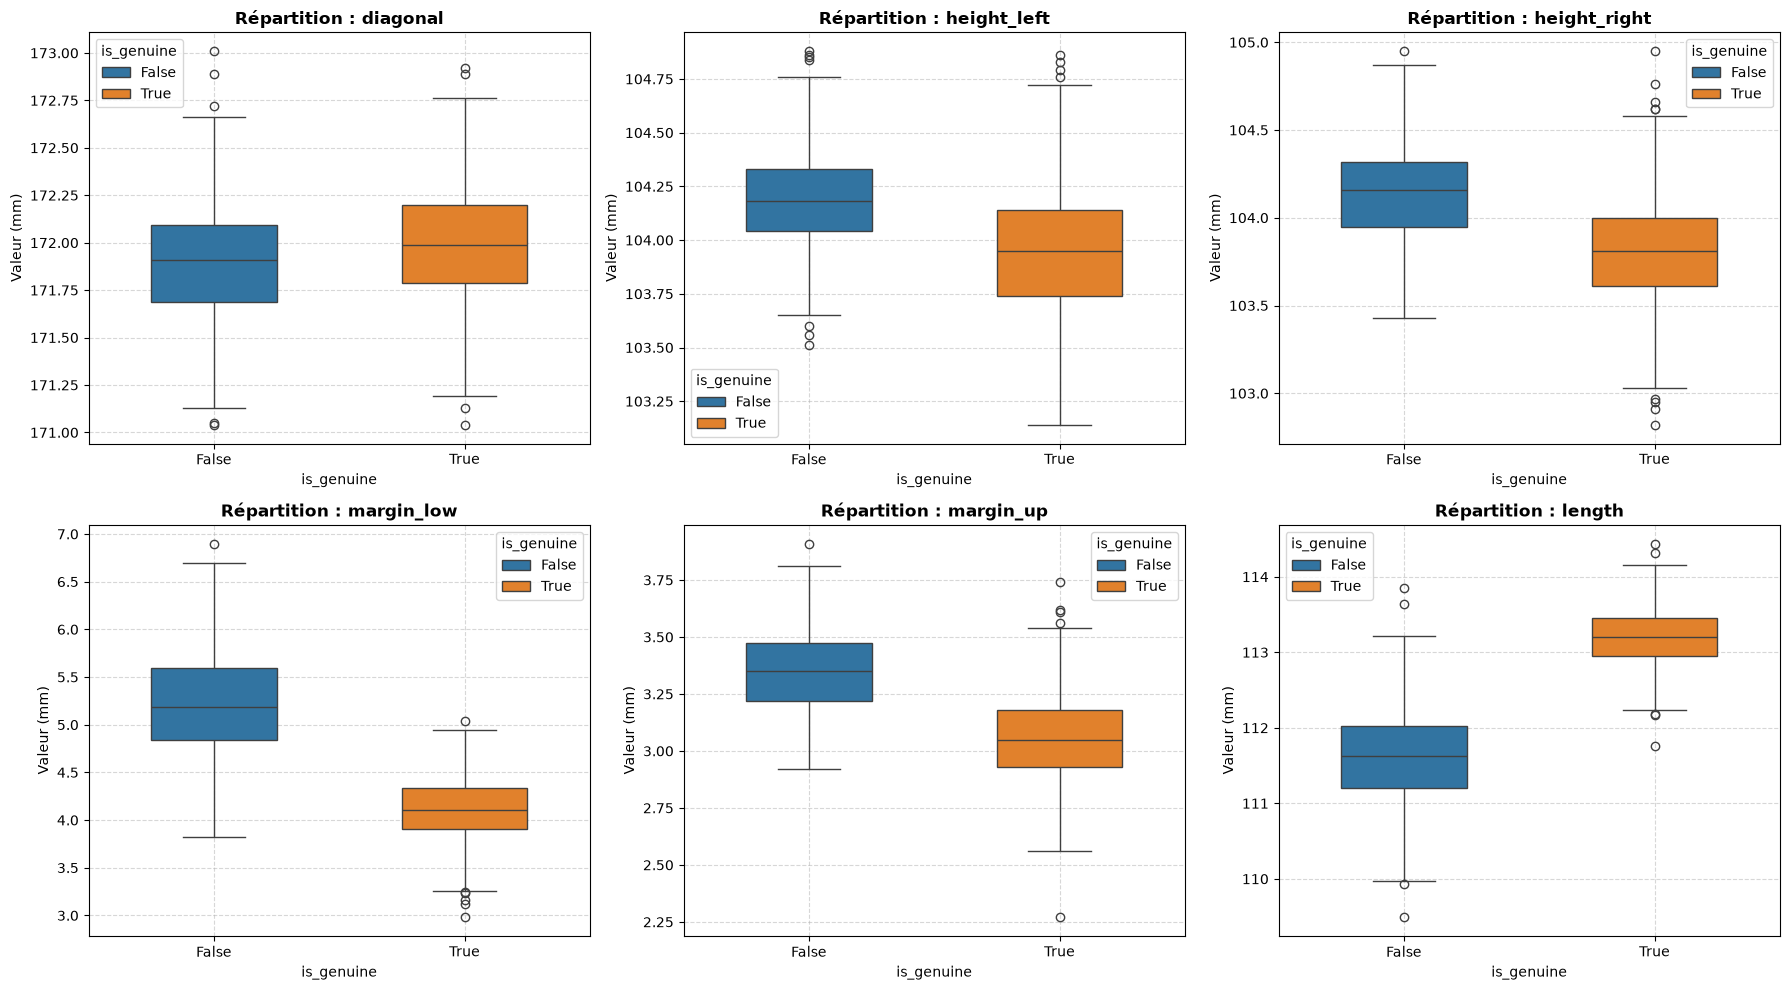

In [59]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# On "aplatit" la grille d'axes pour pouvoir boucler dessus facilement (passer de 2D à 1D)
axes = axes.flatten()

# 3. Boucle pour tracer le boxplot de chaque colonne
for i, col in enumerate(colonnes_dimensions):
    sns.boxplot(
    data=df, x='is_genuine', y=col, ax=axes[i], width=0.5, hue='is_genuine'
)
    # Personnalisation de chaque sous-graphique
    axes[i].set_title(f'Répartition : {col}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Valeur (mm)', fontsize=10)
    axes[i].grid(True, linestyle='--', alpha=0.5)

# 4. Ajustement automatique des espaces pour éviter les chevauchements
plt.tight_layout()
plt.show()

In [49]:
print(df['is_genuine'].value_counts())
print(df['is_genuine'].value_counts(normalize=True) * 100)

is_genuine
True     1000
False     500
Name: count, dtype: int64
is_genuine
True     66.666667
False    33.333333
Name: proportion, dtype: float64


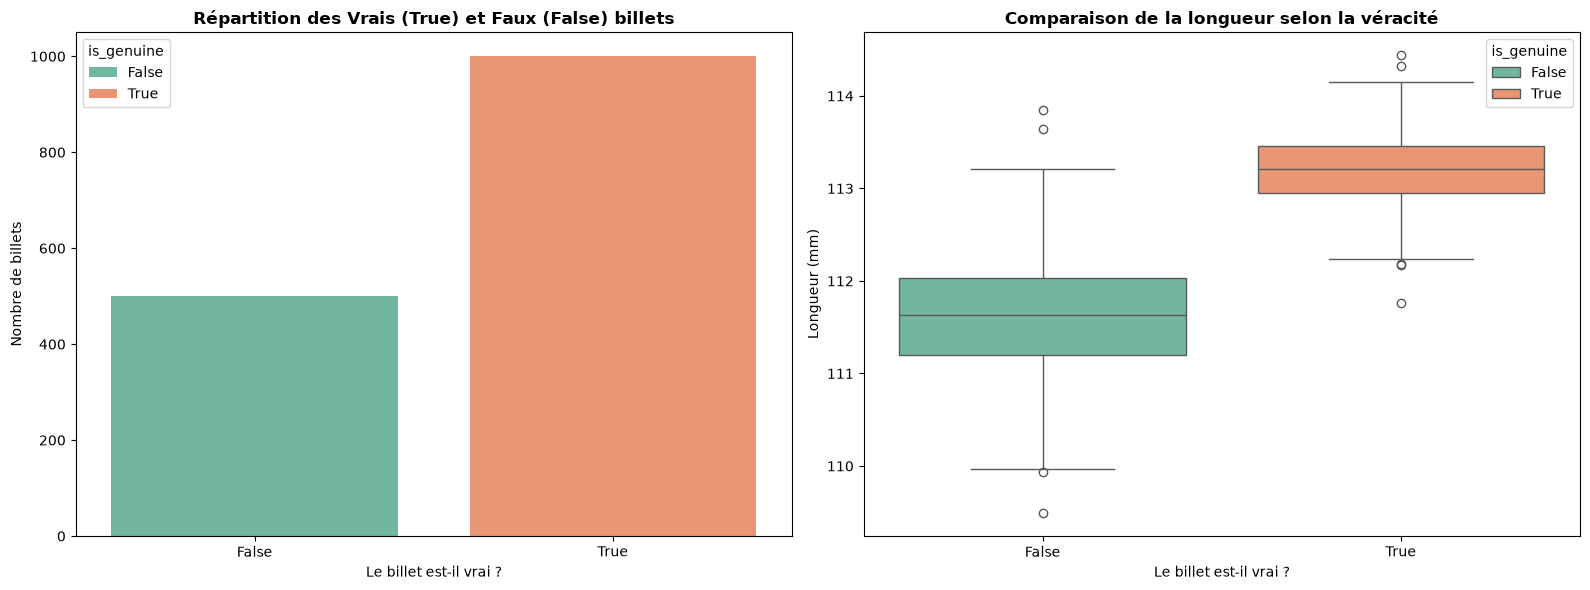

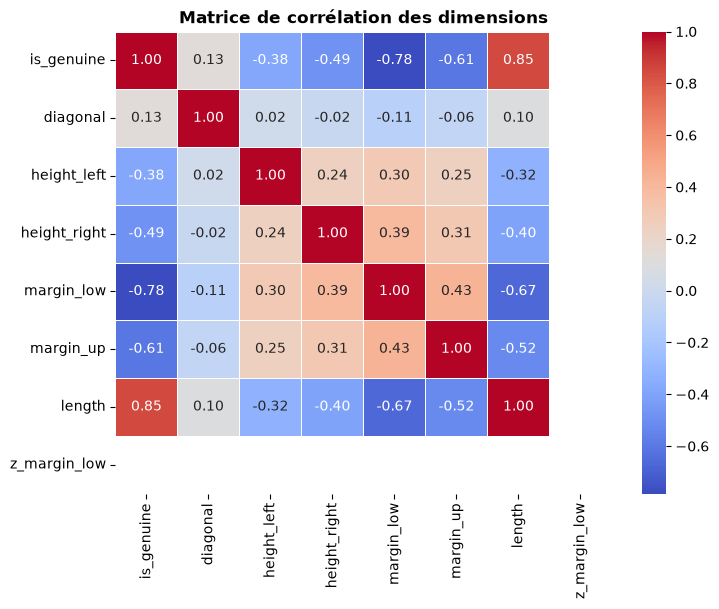

In [50]:
# 3. Création des figures d'analyse descriptive
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Graphique A : Nombre de vrais / faux billets
sns.countplot(data=df, x='is_genuine', ax=axes[0], palette='Set2', hue='is_genuine')
axes[0].set_title("Répartition des Vrais (True) et Faux (False) billets", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Le billet est-il vrai ?")
axes[0].set_ylabel("Nombre de billets")

# Graphique B : focus sur une dimension discriminante (ex: la longueur)
sns.boxplot(data=df, x='is_genuine', y='length', ax=axes[1], palette='Set2', hue='is_genuine')
axes[1].set_title("Comparaison de la longueur selon la véracité", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Le billet est-il vrai ?")
axes[1].set_ylabel("Longueur (mm)")

plt.tight_layout()
plt.show()

# 4. Affichage des corrélations pour voir quelles dimensions sont liées
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Matrice de corrélation des dimensions", fontsize=12, fontweight='bold')
plt.show()

# Régression logistique classique 

# Kmeans

# KNN

# RandomTree